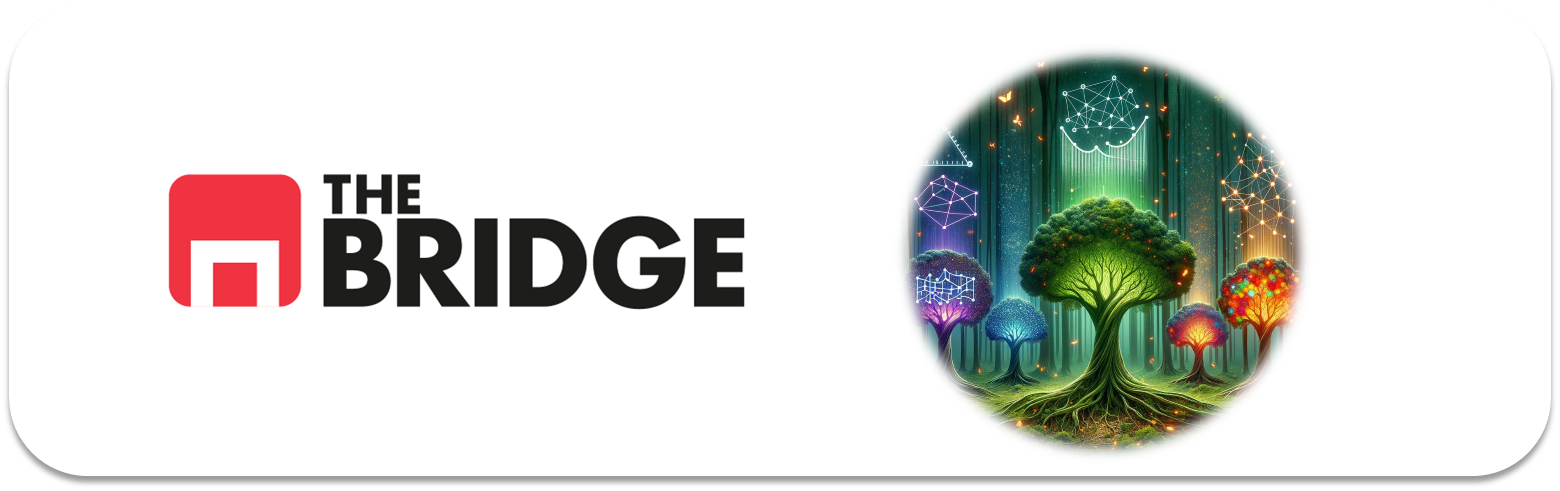

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [162]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

In [163]:
import requests

In [164]:
df = pd.read_csv(url, names= names)

In [165]:
df

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [166]:
target = "class"

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


<Axes: >

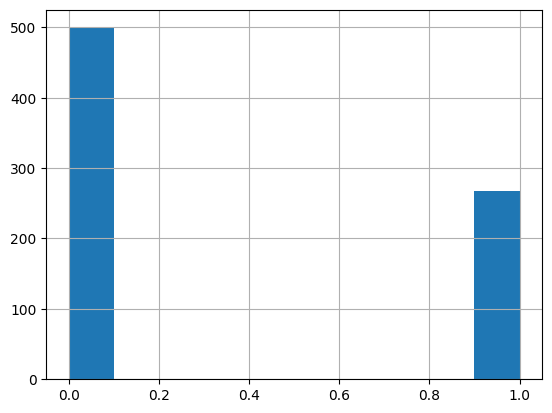

In [168]:
df["class"].hist()

In [169]:
train_df, test_df = train_test_split(df, train_size=0.8, stratify=df["class"])

In [170]:
from bootcampviztools import plot_grouped_histograms

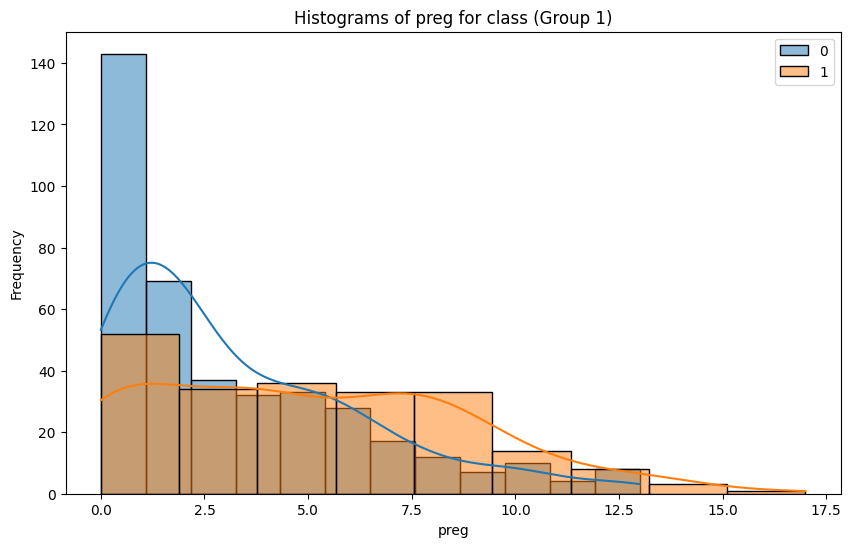

In [171]:
plot_grouped_histograms(train_df, num_col="preg",cat_col="class", group_size=2)

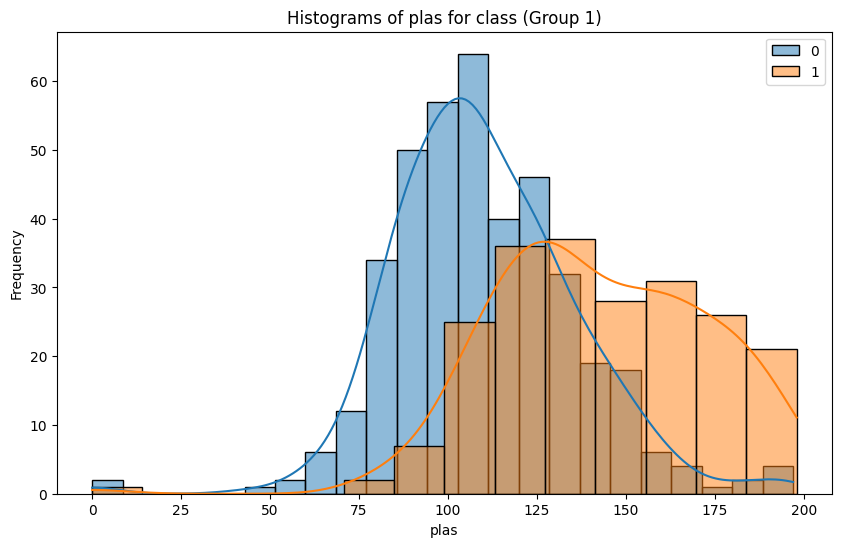

In [172]:
plot_grouped_histograms(train_df, num_col="plas",cat_col="class", group_size=2)

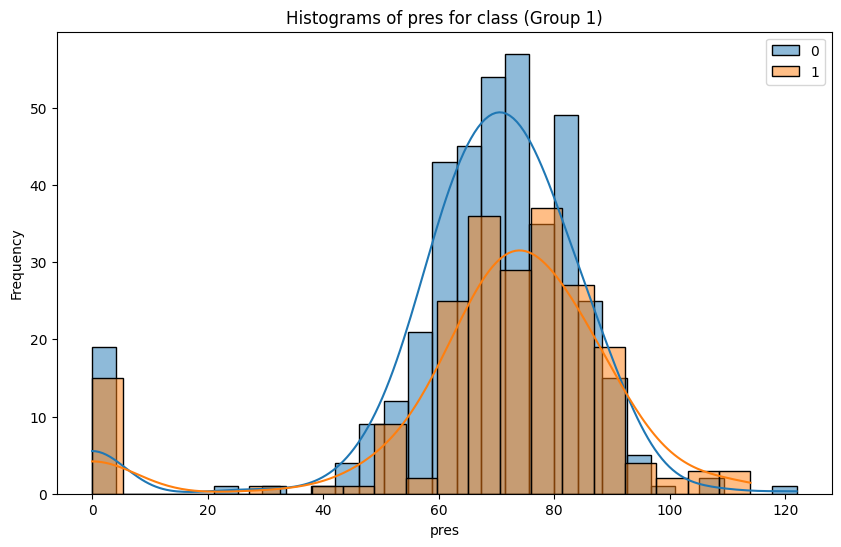

In [173]:
plot_grouped_histograms(train_df, num_col="pres",cat_col="class", group_size=2)

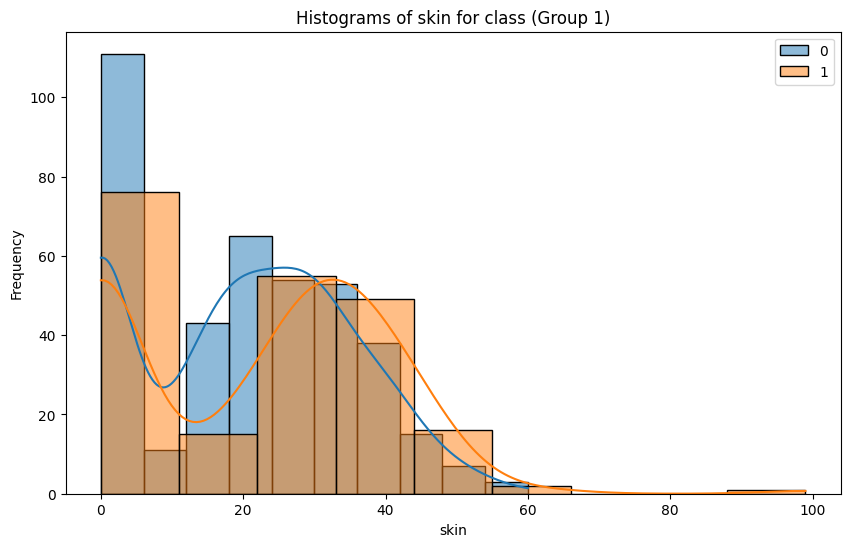

In [174]:
plot_grouped_histograms(train_df, num_col="skin",cat_col="class", group_size=2)

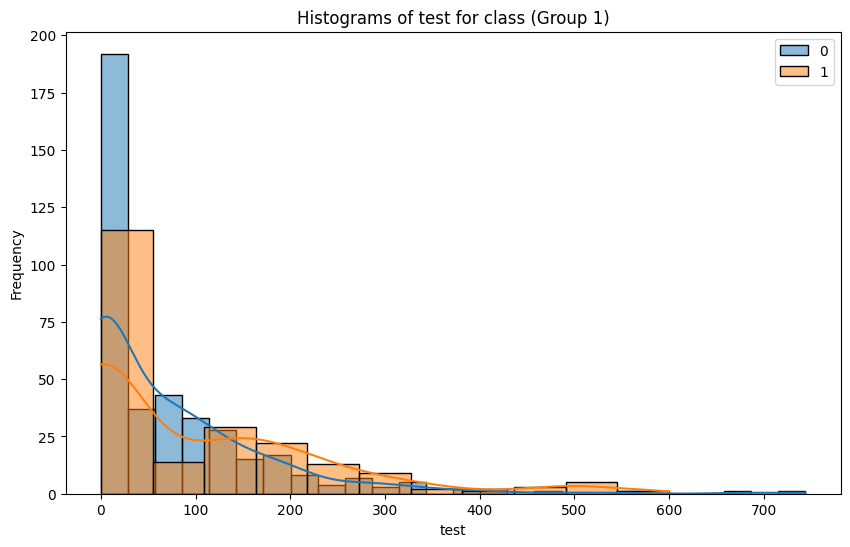

In [175]:
plot_grouped_histograms(train_df, num_col="test",cat_col="class", group_size=2)

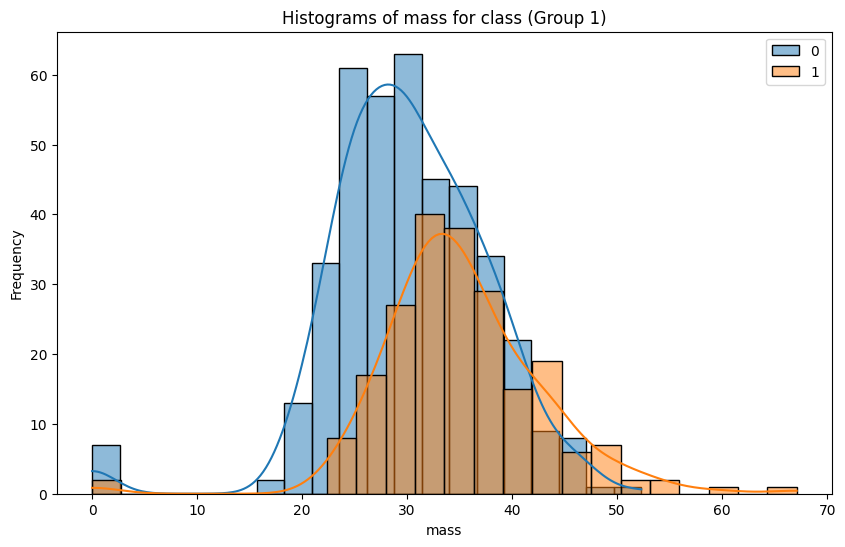

In [176]:
plot_grouped_histograms(train_df, num_col="mass",cat_col="class", group_size=2)

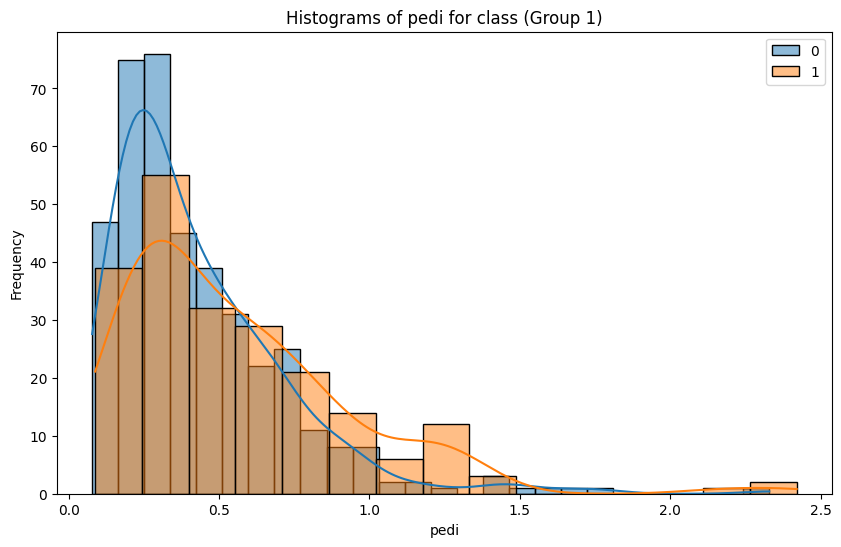

In [177]:
plot_grouped_histograms(train_df, num_col="pedi",cat_col="class", group_size=2)

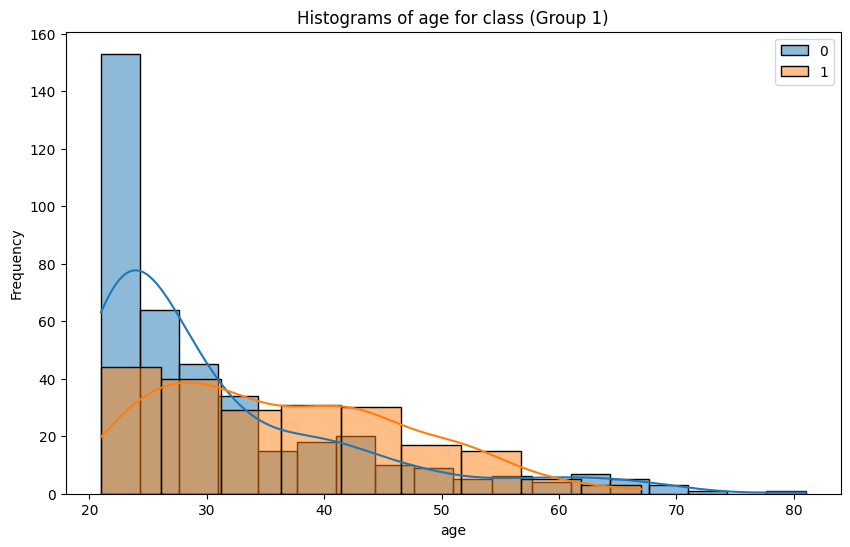

In [178]:
plot_grouped_histograms(train_df, num_col="age",cat_col="class", group_size=2)

In [179]:
train_df.loc[train_df["mass"]==0]

,preg,plas,pres,skin,test,mass,pedi,age,class
706,10,115,0,0,0,0.0,0.261,30,1
81,2,74,0,0,0,0.0,0.102,22,0
9,8,125,96,0,0,0.0,0.232,54,1
494,3,80,0,0,0,0.0,0.174,22,0
60,2,84,0,0,0,0.0,0.304,21,0
522,6,114,0,0,0,0.0,0.189,26,0
426,0,94,0,0,0,0.0,0.256,25,0
49,7,105,0,0,0,0.0,0.305,24,0
684,5,136,82,0,0,0.0,0.640,69,0


In [180]:
train_df["plas"] = train_df["plas"].replace(0,np.nan)
test_df["plas"] = test_df["plas"].replace(0,np.nan)

In [181]:
median_plas = train_df["plas"].median()

train_df["plas"] = train_df["plas"].fillna(median_plas)
test_df["plas"]  = test_df["plas"].fillna(median_plas)


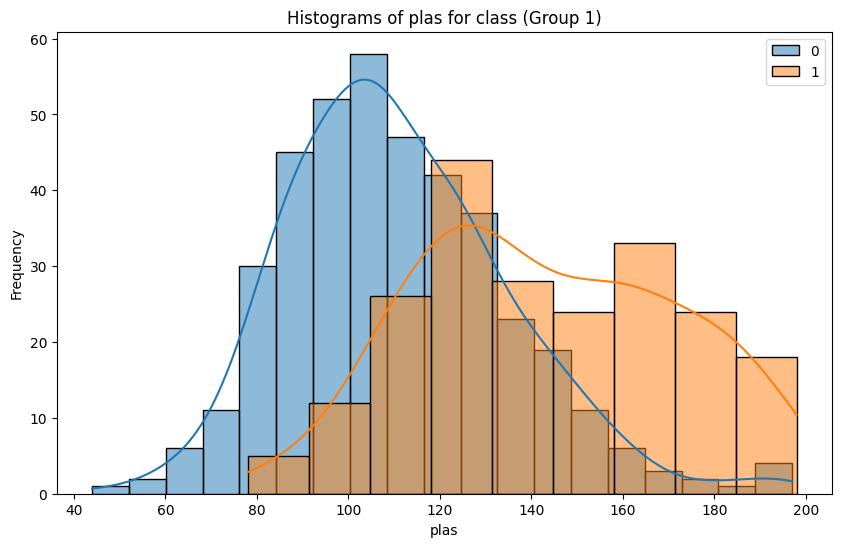

In [182]:
plot_grouped_histograms(train_df, num_col="plas",cat_col="class", group_size=2)

In [183]:

train_df["pres"] = train_df["pres"].replace(0,np.nan)

test_df["pres"] = test_df["pres"].replace(0,np.nan)

In [184]:
median_pres = train_df["pres"].median()

train_df["pres"] = train_df["pres"].fillna(median_pres)
test_df["pres"]  = test_df["pres"].fillna(median_pres)


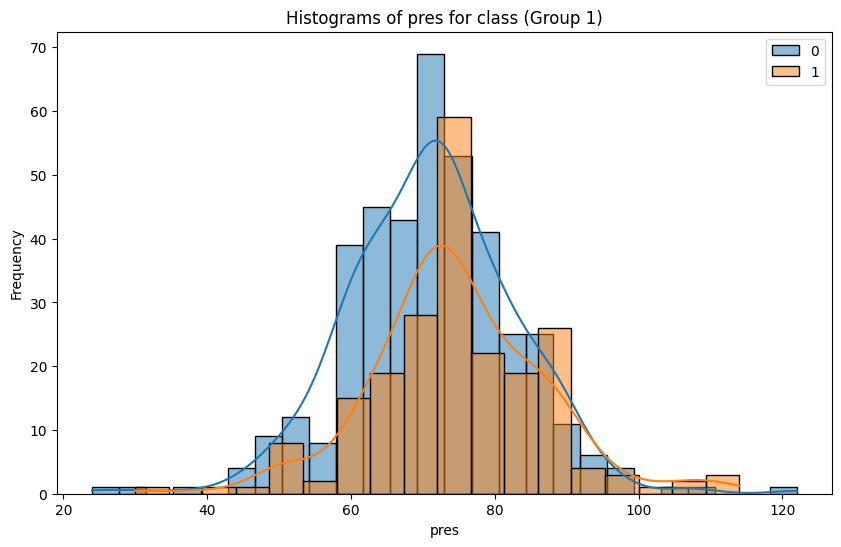

In [185]:
plot_grouped_histograms(train_df, num_col="pres",cat_col="class", group_size=2)

In [186]:
train_df["mass"] = train_df["mass"].replace(0,np.nan)
test_df["mass"] = test_df["mass"].replace(0,np.nan)

In [187]:
median_mass = train_df["mass"].median()
train_df["mass"] = train_df["mass"].fillna(median_mass)
test_df["mass"]  = test_df["mass"].fillna(median_mass)

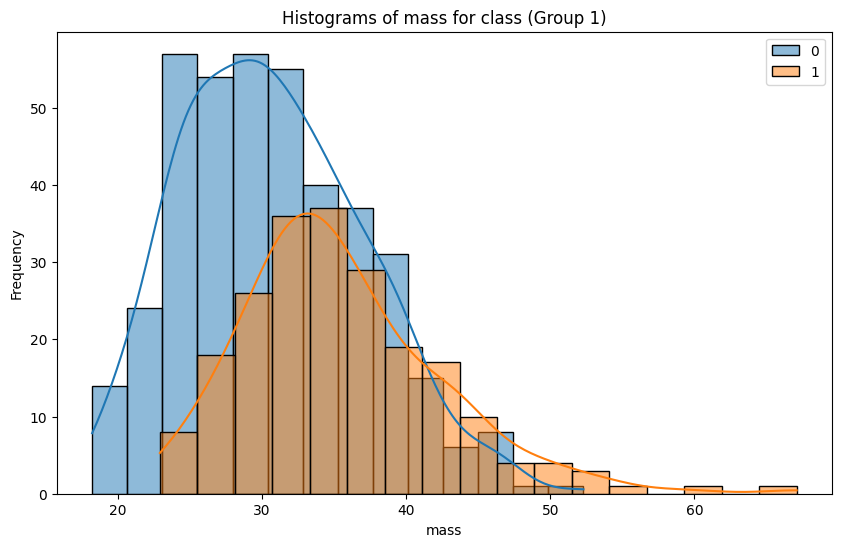

In [188]:
plot_grouped_histograms(train_df, num_col="mass",cat_col="class", group_size=2)

In [189]:
train_df["skin"].value_counts()

skin
0     186
32     25
27     19
30     19
18     18
19     17
33     17
28     15
31     14
40     14
23     14
37     13
25     13
26     12
29     12
41     12
22     12
17     11
24     11
15     11
13     11
20     10
36     10
39     10
35     10
42      8
46      7
12      7
38      7
21      7
44      5
10      5
14      5
34      5
45      5
16      5
11      4
48      4
43      4
47      3
50      3
52      2
49      2
7       2
54      2
56      1
8       1
63      1
51      1
99      1
60      1
Name: count, dtype: int64

In [190]:
train_df["test"].value_counts()

test
0      295
140      8
105      8
130      6
110      5
      ... 
274      1
32       1
51       1
245      1
81       1
Name: count, Length: 171, dtype: int64

In [191]:
train_df["skin_binary"] = train_df["skin"]!=0
test_df["skin_binary"] = test_df["skin"]!=0

In [192]:
train_df["skin_binary"].value_counts()

skin_binary
True     428
False    186
Name: count, dtype: int64

In [193]:
median_skin = train_df["skin"].median()
train_df["skin"] = train_df["skin"].replace(0,median_skin)
test_df["skin"]  = test_df["skin"].replace(0,median_skin)

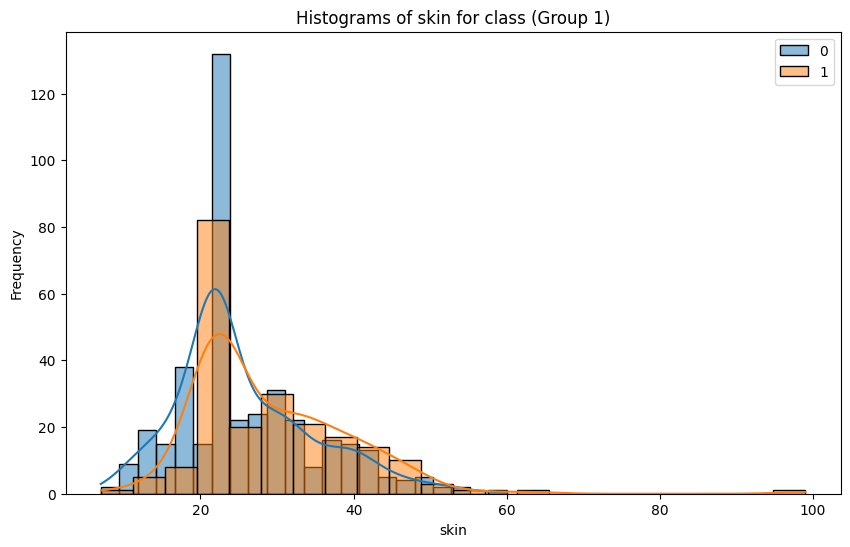

In [194]:
plot_grouped_histograms(train_df, num_col="skin",cat_col="class", group_size=2)

In [195]:
train_df["test_binary"] = train_df["test"]!=0
test_df["test_binary"] = test_df["test"]!=0

In [196]:
median_test = train_df["test"].median()
train_df["test"] = train_df["test"].replace(0,median_test)
test_df["test"]  = test_df["test"].replace(0,median_test)

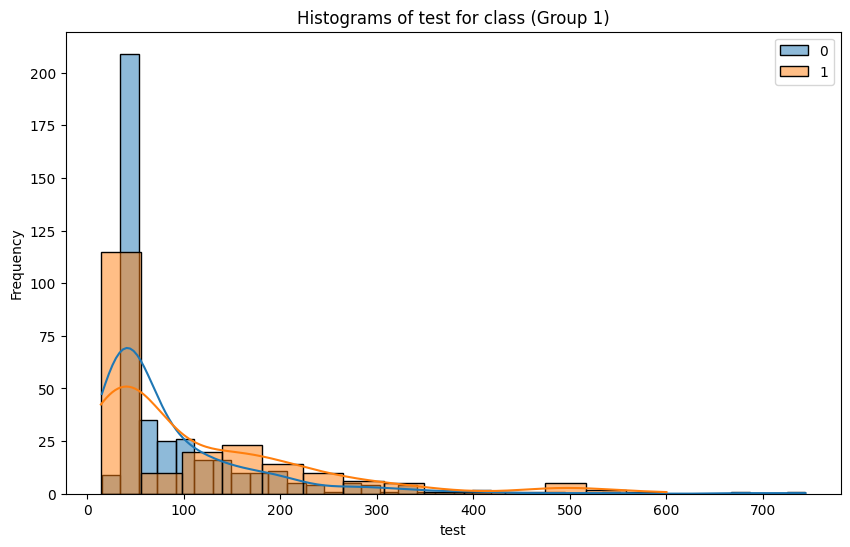

In [197]:
plot_grouped_histograms(train_df, num_col="test",cat_col="class", group_size=2)

In [198]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 738 to 508
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   preg         614 non-null    int64  
 1   plas         614 non-null    float64
 2   pres         614 non-null    float64
 3   skin         614 non-null    int64  
 4   test         614 non-null    int64  
 5   mass         614 non-null    float64
 6   pedi         614 non-null    float64
 7   age          614 non-null    int64  
 8   class        614 non-null    int64  
 9   skin_binary  614 non-null    bool   
 10  test_binary  614 non-null    bool   
dtypes: bool(2), float64(4), int64(5)
memory usage: 49.2 KB


In [199]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 738 to 508
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   preg         614 non-null    int64  
 1   plas         614 non-null    float64
 2   pres         614 non-null    float64
 3   skin         614 non-null    int64  
 4   test         614 non-null    int64  
 5   mass         614 non-null    float64
 6   pedi         614 non-null    float64
 7   age          614 non-null    int64  
 8   class        614 non-null    int64  
 9   skin_binary  614 non-null    bool   
 10  test_binary  614 non-null    bool   
dtypes: bool(2), float64(4), int64(5)
memory usage: 49.2 KB


In [200]:
train_df.columns

Index(['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class',
       'skin_binary', 'test_binary'],
      dtype='object')

In [201]:
numericas = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

In [202]:
booleanas = ['skin_binary', 'test_binary']

array([[<Axes: title={'center': 'preg'}>,
        <Axes: title={'center': 'plas'}>,
        <Axes: title={'center': 'pres'}>],
       [<Axes: title={'center': 'skin'}>,
        <Axes: title={'center': 'test'}>,
        <Axes: title={'center': 'mass'}>],
       [<Axes: title={'center': 'pedi'}>,
        <Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

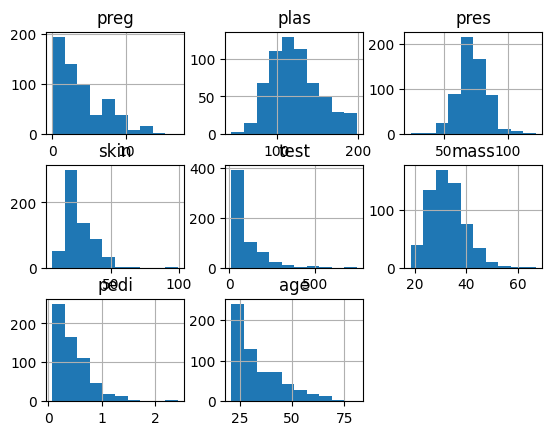

In [203]:
train_df[numericas].hist()

In [204]:
train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

In [205]:
train_df_scaled["test"]=train_df_scaled["test"].apply(lambda x: np.log(x))

In [206]:
train_df_scaled["pedi"]=train_df_scaled["pedi"].apply(lambda x: np.log(x))

In [207]:

test_df_scaled["test"]=test_df_scaled["test"].apply(lambda x: np.log(x))
test_df_scaled["pedi"]=test_df_scaled["pedi"].apply(lambda x: np.log(x))


array([[<Axes: title={'center': 'preg'}>,
        <Axes: title={'center': 'plas'}>,
        <Axes: title={'center': 'pres'}>],
       [<Axes: title={'center': 'skin'}>,
        <Axes: title={'center': 'test'}>,
        <Axes: title={'center': 'mass'}>],
       [<Axes: title={'center': 'pedi'}>,
        <Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

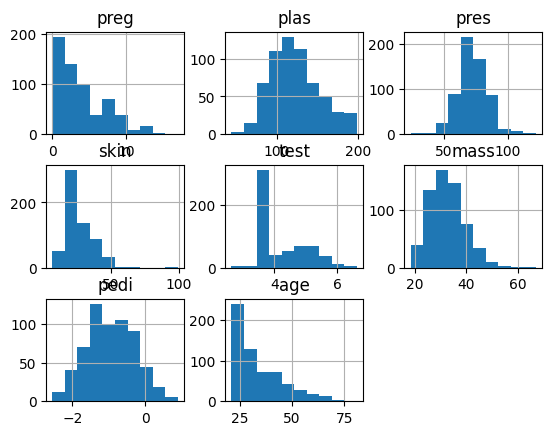

In [208]:
train_df_scaled[numericas].hist()

In [209]:
escalador = StandardScaler()

In [210]:
train_df_scaled.columns

Index(['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class',
       'skin_binary', 'test_binary'],
      dtype='object')

In [211]:
columnas_escalar = ['plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

In [212]:
train_df_scaled[columnas_escalar]=escalador.fit_transform(train_df_scaled[columnas_escalar])

In [213]:
test_df_scaled[columnas_escalar]=escalador.transform(test_df_scaled[columnas_escalar])

In [214]:
train_df_scaled.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,614.000000,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,614.000000
mean,3.885993,-3.471707e-17,-5.012277e-16,-2.893089e-18,-1.591199e-16,3.616362e-16,-1.620130e-16,1.981766e-16,0.348534
std,3.413824,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,0.476895
min,0.000000,-2.594204e+00,-4.060406e+00,-2.059706e+00,-1.974727e+00,-2.055707e+00,-2.460450e+00,-1.039903e+00,0.000000
25%,1.000000,-7.361989e-01,-6.869493e-01,-5.088645e-01,-7.919997e-01,-7.092091e-01,-6.973829e-01,-7.805257e-01,0.000000
50%,3.000000,-1.058043e-01,-3.740171e-02,-5.088645e-01,-7.919997e-01,-5.767806e-02,-1.880070e-02,-3.482302e-01,0.000000
75%,6.000000,6.158317e-01,6.330990e-01,5.250296e-01,8.159431e-01,6.083314e-01,7.482287e-01,6.028199e-01,1.000000
max,17.000000,2.515310e+00,4.153228e+00,7.452120e+00,3.000548e+00,5.024264e+00,2.844765e+00,4.147643e+00,1.000000


In [215]:
x_train_df = train_df.drop(columns="class")
y_train_df = train_df["class"]
x_train_df_scaled = train_df_scaled.drop(columns="class")
y_train_df_scaled = train_df_scaled["class"]

In [216]:
x_test_df = test_df.drop(columns="class")
y_test_df = test_df["class"]
x_test_df_scaled = test_df_scaled.drop(columns="class")
y_test_df_scaled = test_df_scaled["class"]

In [217]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [218]:
random_forest = RandomForestClassifier(max_depth=10)
xgboost = XGBClassifier()
lightgbm = LGBMClassifier()

In [219]:
np.mean(cross_val_score(random_forest,x_train_df,y_train_df, cv=5))

np.float64(0.7801012928162068)

In [220]:
np.mean(cross_val_score(random_forest,x_train_df_scaled,y_train_df_scaled,cv=5))

np.float64(0.7703185392509663)

In [221]:
np.mean(cross_val_score(xgboost,x_train_df,y_train_df,cv=5))

np.float64(0.7539917366386779)

In [222]:
np.mean(cross_val_score(xgboost,x_train_df_scaled,y_train_df_scaled,cv=5))

np.float64(0.7539917366386779)

In [223]:
np.mean(cross_val_score(lightgbm,x_train_df,y_train_df, cv=5))

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 588
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,348269 -> initscore=-0,626657
[LightGBM] [Info] Start training from score -0,626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

np.float64(0.74911368785819)

In [224]:
np.mean(cross_val_score(lightgbm,x_train_df_scaled,y_train_df_scaled, cv=5))

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000055 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 587
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,348269 -> initscore=-0,626657
[LightGBM] [Info] Start training from score -0,626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

np.float64(0.7621618019458882)

In [225]:
random_forest.fit(x_train_df,y_train_df)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [226]:
predicts = random_forest.predict(x_test_df)

In [227]:
from sklearn.metrics import classification_report

In [228]:
print(classification_report(y_test_df,predicts))

              precision    recall  f1-score   support

           0       0.74      0.85      0.79       100
           1       0.62      0.44      0.52        54

    accuracy                           0.71       154
   macro avg       0.68      0.65      0.65       154
weighted avg       0.70      0.71      0.69       154



In [229]:
random_forest2 = RandomForestClassifier(max_depth=10)

In [230]:
random_forest2.fit(x_train_df_scaled,y_train_df_scaled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [231]:
predicts2 = random_forest2.predict(x_test_df_scaled)

In [232]:
print(classification_report(y_test_df_scaled,predicts2))

              precision    recall  f1-score   support

           0       0.77      0.87      0.82       100
           1       0.68      0.52      0.59        54

    accuracy                           0.75       154
   macro avg       0.73      0.69      0.70       154
weighted avg       0.74      0.75      0.74       154



In [233]:
RandomForestClassifier()

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [257]:
grid = {"n_estimators":[50,100,200],
        "max_depth":[2,6,10],
        "min_samples_split":[2,4,8,16,32],
        "min_samples_leaf":[1,2,4,8],
        "max_features": ["sqrt","log2",None],
        "max_samples": [0.3,0.6,1],
        "class_weight":[None,"balanced"]}

In [258]:
grid = GridSearchCV(random_forest,
                    param_grid=grid,
                    cv=5,
                    scoring = "balanced_accuracy",
                    n_jobs=-1)

In [259]:
grid.fit(x_train_df_scaled,y_train_df_scaled)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...(max_depth=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [2, 6, ...], 'max_features': ['sqrt', 'log2', ...], 'max_samples': [0.3, 0.6, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [260]:
grid.best_score_

np.float64(0.7897397563676634)

In [286]:
grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 10,
 'max_features': 'log2',
 'max_samples': 0.6,
 'min_samples_leaf': 1,
 'min_samples_split': 32,
 'n_estimators': 50}

In [263]:
arbol_final = RandomForestClassifier(max_depth= 10,
 max_features= "log2",
 max_samples= 0.6,
 min_samples_leaf= 1,
 min_samples_split= 32,
 n_estimators= 50,
 class_weight="balanced")

In [287]:
arbol_final.fit(x_train_df_scaled,y_train_df_scaled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",32
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [288]:
predicciones3 = arbol_final.predict(x_test_df_scaled)

In [289]:
print(classification_report(y_test_df_scaled,predicciones3))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.65      0.66        54

    accuracy                           0.77       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



In [280]:
features = arbol_final.feature_importances_.T

In [277]:
nombres = arbol_final.feature_names_in_.tolist()

In [ ]:
nombres = nombres

['preg',
 'plas',
 'pres',
 'skin',
 'test',
 'mass',
 'pedi',
 'age',
 'skin_binary',
 'test_binary']

In [285]:
pd.DataFrame(features, index=nombres).sort_values(by=0, ascending=False)

,0
plas,0.393508
mass,0.184503
age,0.125027
pedi,0.087186
preg,0.066302
skin,0.050464
test,0.044644
pres,0.040489
skin_binary,0.006924
test_binary,0.000954


In [308]:
y_proba = arbol_final.predict_proba(x_test_df_scaled)[:, 1]
y_pred = (y_proba >= 0.2).astype(int)  # prueba varios valores


In [309]:
print(classification_report(y_test_df_scaled,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.35      0.51       100
           1       0.44      0.96      0.61        54

    accuracy                           0.56       154
   macro avg       0.70      0.66      0.56       154
weighted avg       0.77      0.56      0.55       154

